## **Clone the repo**

In [1]:
!git clone https://github.com/IT25100310/Indoor-Plant-Disease-Dataset.git

Cloning into 'Indoor-Plant-Disease-Dataset'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 74 (delta 28), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 2.15 MiB | 8.09 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [2]:
!ls

Indoor-Plant-Disease-Dataset  sample_data


In [3]:
%cd Indoor-Plant-Disease-Dataset

/content/Indoor-Plant-Disease-Dataset


In [4]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [6]:
!git config --global user.email "it25103102@my.sliit.lk"
!git config --global user.name "IT25103105"

!git checkout -b IT25103102-outliers

!git status

fatal: a branch named 'IT25103102-outliers' already exists
On branch IT25103102-outliers
nothing to commit, working tree clean


# **start from the latest [main]**

In [7]:
%cd /content/Indoor-Plant-Disease-Dataset
!find . -name "*.ipynb"

/content/Indoor-Plant-Disease-Dataset


# Confirm you're in the right place and it's a real git repo

In [8]:
!pwd
!git status

/content/Indoor-Plant-Disease-Dataset
On branch IT25103102-outliers
nothing to commit, working tree clean


# **Create your branch**

In [9]:
!git checkout -b IT25103102-outliers

fatal: a branch named 'IT25103102-outliers' already exists


# **Create the notebooks folder**

In [10]:
!mkdir -p notebooks

# **Import kaggle.json**

In [11]:
import json
import os

# NOTE: Replace with your own Kaggle username/key before running
kaggle_creds = {
    "username": "YOUR_KAGGLE_USERNAME",
    "key": "YOUR_KAGGLE_KEY"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

In [12]:
!kaggle datasets download -d aditisalvi04/indoor-plant-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/aditisalvi04/indoor-plant-disease-dataset
License(s): MIT
100% 7.79G/7.79G [01:37<00:00, 86.0MB/s]



# **Unzip dataset**

In [13]:
!mkdir -p /content/data/raw
!unzip -q indoor-plant-disease-dataset.zip -d /content/data/raw/

In [14]:
#verify

!ls /content/data/raw/

'Final Dataset'


# **Get dataset structure**

In [15]:
import os

data_path = "/content/data/raw/"

for root, dirs, files in os.walk(data_path):
    depth = root[len(data_path):].count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/  ({len(files)} files, {len(dirs)} subdirs)")
    if depth > 2:  # don't spam the whole tree
        dirs[:] = []

/content/data/raw//  (0 files, 1 subdirs)
Final Dataset/  (0 files, 6 subdirs)
  Turmeric/  (0 files, 5 subdirs)
    Turmeric_Leaf_Necrosis/  (812 files, 0 subdirs)
    Turmeric_Blotch/  (1904 files, 0 subdirs)
    Turmeric_Healthy/  (1806 files, 0 subdirs)
    Turmeric_Leaf_Spot/  (919 files, 0 subdirs)
    Turmeric_Aphid_Infestation/  (847 files, 0 subdirs)
  Money Plant/  (0 files, 4 subdirs)
    Money_Plant_Chlorosis/  (115 files, 0 subdirs)
    Money_Plant_Healthy/  (2760 files, 0 subdirs)
    Money_Plant_Manganese_Toxicity/  (596 files, 0 subdirs)
    Money_Plant_Bacterial_Wilt/  (576 files, 0 subdirs)
  Rose/  (0 files, 8 subdirs)
    Rose_Black_Spot/  (3000 files, 0 subdirs)
    Rose_Insect_Damage/  (2812 files, 0 subdirs)
    Rose_Downy_Mildew/  (1102 files, 0 subdirs)
    Rose_Yellow_Mosaic_Virus/  (680 files, 0 subdirs)
    Rose_Powdery_Mildew/  (1000 files, 0 subdirs)
    Rose_Rust/  (1000 files, 0 subdirs)
    Rose_Healthy/  (5530 files, 0 subdirs)
    Rose_Mosaic_Virus/  

In [16]:
data_path = "/content/data/raw/Final Dataset"

# Build the real class list: one entry per disease/health folder, two levels deep
class_folders = {}  # class_name -> full folder path
for plant in os.listdir(data_path):
    plant_path = os.path.join(data_path, plant)
    if not os.path.isdir(plant_path):
        continue
    for disease_folder in os.listdir(plant_path):
        full_path = os.path.join(plant_path, disease_folder)
        if os.path.isdir(full_path):
            class_folders[disease_folder] = full_path

classes = sorted(class_folders.keys())
print(f"Total classes: {len(classes)}")
print(classes)

Total classes: 29
['Aloe_Anthracnose', 'Aloe_Healthy', 'Aloe_Leaf_Spot', 'Aloe_Rust', 'Aloe_Sunburn', 'Chrysanthemum_Bacterial_Leaf_Spot', 'Chrysanthemum_Healthy', 'Chrysanthemum_Septoria_Leaf_Spot', 'Hibiscus_Blight', 'Hibiscus_Healthy', 'Hibiscus_Necrosis', 'Hibiscus_Scorch', 'Money_Plant_Bacterial_Wilt', 'Money_Plant_Chlorosis', 'Money_Plant_Healthy', 'Money_Plant_Manganese_Toxicity', 'Rose_Black_Spot', 'Rose_Downy_Mildew', 'Rose_Healthy', 'Rose_Insect_Damage', 'Rose_Mosaic_Virus', 'Rose_Powdery_Mildew', 'Rose_Rust', 'Rose_Yellow_Mosaic_Virus', 'Turmeric_Aphid_Infestation', 'Turmeric_Blotch', 'Turmeric_Healthy', 'Turmeric_Leaf_Necrosis', 'Turmeric_Leaf_Spot']


# **Outlier Detection and Removal**

**IT25103102** — Preprocessing Technique: Outlier Detection & Removal

Since this is an image dataset (not tabular numeric data), outliers are identified using measurable image-level properties: **file size, dimensions, and mean pixel brightness**, combined with corrupt-file detection.

In [17]:
# IT25103102 - Outlier Detection & Removal

import cv2
import numpy as np
import pandas as pd

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

# Set to a number (e.g. 300) to sample per class for faster testing,
# or None to scan the FULL dataset (slower, ~49,900 images)
SAMPLE_PER_CLASS = 300

image_records = []
corrupt_files = []

# ---- 1. Scan images and collect properties ----
for class_name, folder_path in class_folders.items():
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)]
    if SAMPLE_PER_CLASS is not None:
        files = files[:SAMPLE_PER_CLASS]

    for fname in files:
        fpath = os.path.join(folder_path, fname)
        try:
            img = cv2.imread(fpath)
            if img is None:
                corrupt_files.append(fpath)
                continue

            file_size_kb = os.path.getsize(fpath) / 1024
            h, w = img.shape[:2]
            mean_brightness = img.mean()

            image_records.append({
                'filepath': fpath,
                'class': class_name,
                'width': w,
                'height': h,
                'file_size_kb': file_size_kb,
                'mean_brightness': mean_brightness
            })
        except Exception:
            corrupt_files.append(fpath)

df_images = pd.DataFrame(image_records)
print("Total valid images scanned:", len(df_images))
print("Corrupt/unreadable images found:", len(corrupt_files))
df_images.head()

Total valid images scanned: 8515
Corrupt/unreadable images found: 0


,filepath,class,width,height,file_size_kb,mean_brightness
0,/content/data/raw/Final Dataset/Turmeric/Turme...,Turmeric_Leaf_Necrosis,1000,1000,731.883789,164.697446
1,/content/data/raw/Final Dataset/Turmeric/Turme...,Turmeric_Leaf_Necrosis,1000,1000,487.151367,117.352015
2,/content/data/raw/Final Dataset/Turmeric/Turme...,Turmeric_Leaf_Necrosis,1000,1000,491.432617,111.705560
3,/content/data/raw/Final Dataset/Turmeric/Turme...,Turmeric_Leaf_Necrosis,1000,1000,656.757812,218.006010
4,/content/data/raw/Final Dataset/Turmeric/Turme...,Turmeric_Leaf_Necrosis,1000,1000,554.790039,199.009779


In [18]:
# ---- 2. IQR Method to detect outliers in numeric features ----
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_size, low_size, high_size = detect_outliers_iqr(df_images, 'file_size_kb')
outliers_brightness, low_bright, high_bright = detect_outliers_iqr(df_images, 'mean_brightness')

print(f"File size outliers: {len(outliers_size)}  (bounds: {low_size:.2f} - {high_size:.2f} KB)")
print(f"Brightness outliers: {len(outliers_brightness)}  (bounds: {low_bright:.2f} - {high_bright:.2f})")

# Combine all outlier filepaths (union of both checks)
outlier_filepaths = set(outliers_size['filepath']).union(set(outliers_brightness['filepath']))
print("Total unique outlier images:", len(outlier_filepaths))

File size outliers: 1315  (bounds: -187.72 - 327.50 KB)
Brightness outliers: 0  (bounds: -26.89 - 304.19)
Total unique outlier images: 1315


# **EDA Visualization: Boxplots**

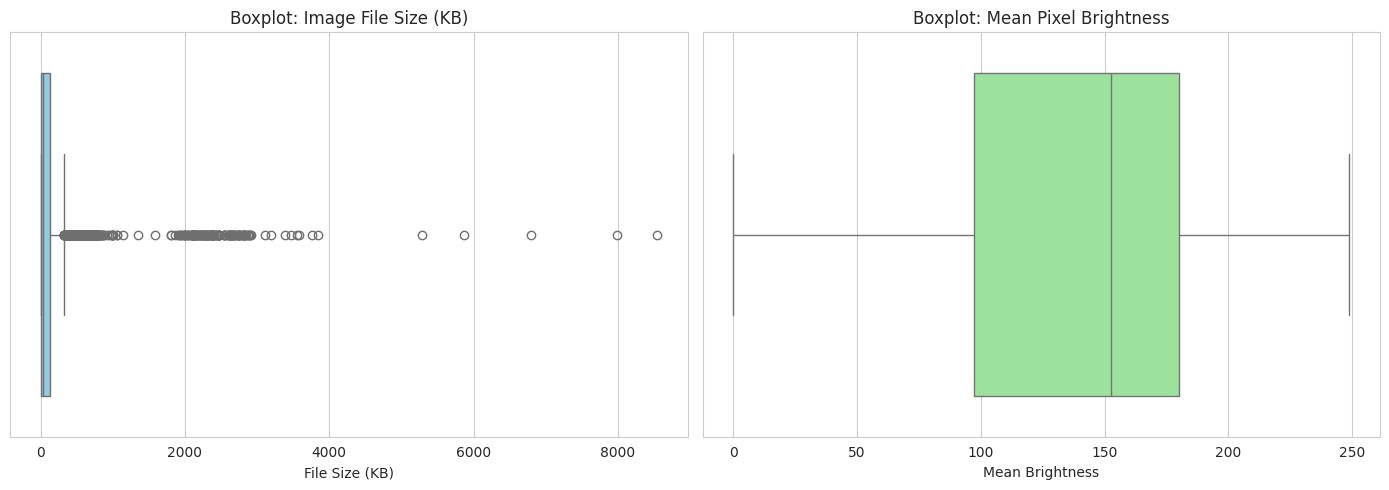

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df_images['file_size_kb'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: Image File Size (KB)')
axes[0].set_xlabel('File Size (KB)')

sns.boxplot(x=df_images['mean_brightness'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Mean Pixel Brightness')
axes[1].set_xlabel('Mean Brightness')

plt.tight_layout()

os.makedirs("/content/Indoor-Plant-Disease-Dataset/results/eda_visualizations", exist_ok=True)
plt.savefig("/content/Indoor-Plant-Disease-Dataset/results/eda_visualizations/IT25103102_outlier_boxplots.png")
plt.show()

**Interpretation:** Points beyond the whiskers in each boxplot are statistically unusual file sizes or brightness values compared to the rest of the dataset. These could be corrupt images, images from a different source, or extreme lighting conditions. These flagged images are reviewed and removed in the next step.

# **Class Distribution Before Removal**

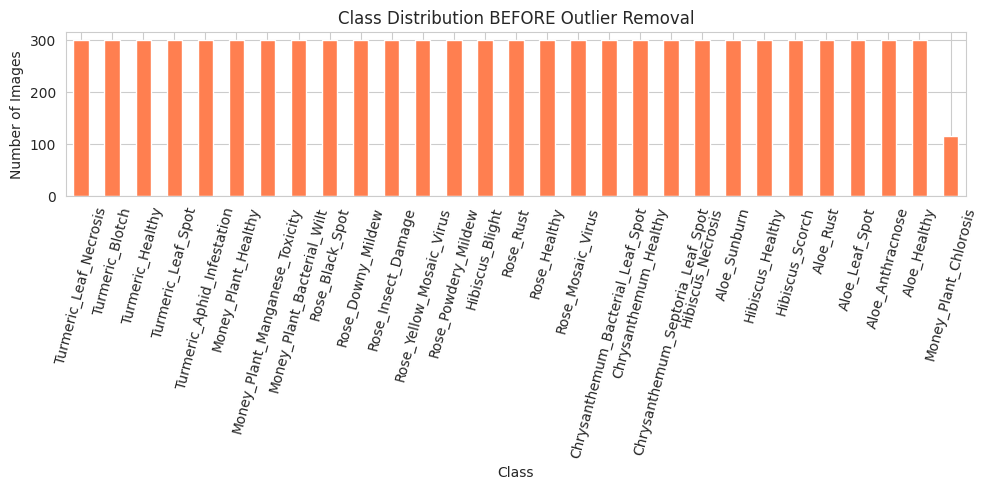

In [20]:
plt.figure(figsize=(10, 5))
df_images['class'].value_counts().plot(kind='bar', color='coral')
plt.title('Class Distribution BEFORE Outlier Removal')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("/content/Indoor-Plant-Disease-Dataset/results/eda_visualizations/IT25103102_class_distribution_before.png")
plt.show()

# **Remove Outliers and Corrupt Files**

In [21]:
# ---- 3. Remove outliers from the dataframe ----
df_clean = df_images[~df_images['filepath'].isin(outlier_filepaths)].reset_index(drop=True)

print("Before removal:", len(df_images))
print("After removal:", len(df_clean))
print("Removed (outliers):", len(df_images) - len(df_clean))
print("Removed (corrupt, unreadable):", len(corrupt_files))

Before removal: 8515
After removal: 7200
Removed (outliers): 1315
Removed (corrupt, unreadable): 0


# **Class Distribution After Removal (balance check)**

Class distribution BEFORE removal:
class
Turmeric_Leaf_Necrosis               300
Turmeric_Blotch                      300
Turmeric_Healthy                     300
Turmeric_Leaf_Spot                   300
Turmeric_Aphid_Infestation           300
Money_Plant_Healthy                  300
Money_Plant_Manganese_Toxicity       300
Money_Plant_Bacterial_Wilt           300
Rose_Black_Spot                      300
Rose_Downy_Mildew                    300
Rose_Insect_Damage                   300
Rose_Yellow_Mosaic_Virus             300
Rose_Powdery_Mildew                  300
Hibiscus_Blight                      300
Rose_Rust                            300
Rose_Healthy                         300
Rose_Mosaic_Virus                    300
Chrysanthemum_Bacterial_Leaf_Spot    300
Chrysanthemum_Healthy                300
Chrysanthemum_Septoria_Leaf_Spot     300
Hibiscus_Necrosis                    300
Aloe_Sunburn                         300
Hibiscus_Healthy                     300
Hibiscus_Scorch 

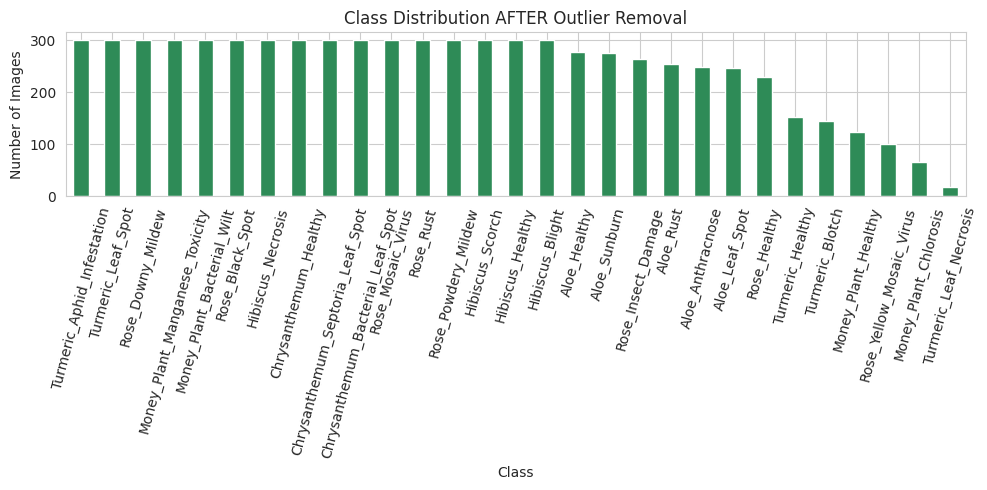

In [22]:
print("Class distribution BEFORE removal:")
print(df_images['class'].value_counts())

print("\nClass distribution AFTER removal:")
print(df_clean['class'].value_counts())

plt.figure(figsize=(10, 5))
df_clean['class'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Class Distribution AFTER Outlier Removal')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("/content/Indoor-Plant-Disease-Dataset/results/eda_visualizations/IT25103102_class_distribution_after.png")
plt.show()

# **Save Cleaned Metadata for Group Pipeline**

In [23]:
# ---- 4. Save cleaned metadata (used by group_pipeline.ipynb) ----
os.makedirs("/content/Indoor-Plant-Disease-Dataset/results/outputs", exist_ok=True)
df_clean.to_csv("/content/Indoor-Plant-Disease-Dataset/results/outputs/IT25103102_cleaned_image_metadata.csv", index=False)

if corrupt_files:
    with open("/content/Indoor-Plant-Disease-Dataset/results/logs/IT25103102_corrupt_files.txt", "w") as f:
        f.write("\n".join(corrupt_files))

print("Cleaned metadata and logs saved.")

Cleaned metadata and logs saved.
